# Event 07 — FTX 파산 (2022.11)
## 스토리텔링 차트 (Scrollytelling Stepper)

### 배경
2022년 11월 2일 CoinDesk의 폭로 기사로 시작된 9일간의 붕괴. **기업가치 $32B → $0**. 세계 2위 가상자산 거래소가 일주일 만에 파산(Chapter 11).

### 핵심 관전 포인트
- **크립토-주식 디커플링**: FTX가 무너지는 동안 SP500은 오히려 상승 (11/10 +5.5% CPI 호재 랠리). 2022년 Fed 긴축으로 크립토가 "주류 자산"에서 고립된 순간.
- **전염의 그림자**: BTC -23%, ETH -30%. 크립토 겨울이 한층 깊어짐.

### 출력
- `data/figures/e07_story/00_prologue.png` … `05_act5.png`
- `data/figures/e07_story/99_summary.png`

## 1. Imports & 데이터 로드

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
PANEL = ROOT / 'data' / 'processed' / 'panel_daily.csv'
FIG_DIR = ROOT / 'data' / 'figures' / 'e07_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

p = pd.read_csv(PANEL, index_col=0, parse_dates=True)
df = p.loc['2022-10-15':'2022-12-31', ['BTC-USD','ETH-USD','SP500']].copy()
df.columns = ['BTC','ETH','SP500']
print(f'shape: {df.shape}, {df.index.min().date()} ~ {df.index.max().date()}')
print(f'BTC  range: ${df.BTC.min():.0f} ~ ${df.BTC.max():.0f}')
print(f'ETH  range: ${df.ETH.min():.0f} ~ ${df.ETH.max():.0f}')
print(f'SP500 range: ${df.SP500.min():.0f} ~ ${df.SP500.max():.0f}')

shape: (55, 3), 2022-10-17 ~ 2022-12-30
BTC  range: $15787 ~ $21147
ETH  range: $1100 ~ $1645
SP500 range: $3666 ~ $4080


## 2. 6국면 정의 (일주일간의 붕괴)

In [2]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 평온한 10월',
        'start': '2022-10-15', 'end': '2022-11-01', 'color': '#90A4AE',
        'narrative': 'BTC $19~20K, ETH $1,500대로 크립토 겨울이 안정화된 듯 보였다. FTX는 세계 2위 거래소, 기업가치 $32B.',
        'hero_annotations': [
            ('2022-10-31', 'BTC', 20496, '$20K 안정', (-50, 25), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — CoinDesk 폭로 (11/2)',
        'start': '2022-11-02', 'end': '2022-11-05', 'color': '#FFB74D',
        'narrative': '11/2 CoinDesk가 알라메다(FTX 자매 헤지펀드) 재무상태표의 대부분이 자체 발행 토큰 FTT임을 폭로. 시장은 "탈중앙 거래소의 중앙집중 리스크"를 깨닫기 시작.',
        'hero_annotations': [
            ('2022-11-02', 'BTC', 20160, '⭐ CoinDesk 폭로\n알라메다 FTT 집중', (-100, 20), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — CZ 트윗 & 뱅크런 (11/6~8)',
        'start': '2022-11-06', 'end': '2022-11-08', 'color': '#E53935',
        'narrative': '11/6 Binance CEO CZ가 "FTT 보유분 매도" 트윗. 즉각 뱅크런 개시. FTT 가격 붕괴, BTC는 11/8에 $18,541 (하루 -10%).',
        'hero_annotations': [
            ('2022-11-08', 'BTC', 18541, 'CZ 트윗 → 뱅크런\nBTC -10% (하루)', (15, 20), 'left'),
            ('2022-11-08', 'ETH',  1333, 'ETH -15%', (15, -25), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — Binance 철수 (11/9)',
        'start': '2022-11-09', 'end': '2022-11-09', 'color': '#B71C1C',
        'narrative': '11/8 저녁 Binance가 FTX 인수 의향서(LOI) 발표 → 24시간 뒤 실사 후 철회. FTX 구제 최후 희망 소멸. **BTC는 장중 $15,881 저점** (ATH 대비 -77%).',
        'hero_annotations': [
            ('2022-11-09', 'BTC', 15881, '⭐ Binance 철수\nBTC 저점 $15,881', (15, 25), 'left'),
            ('2022-11-09', 'ETH',  1100, 'ETH $1,100\n(30% 하락)', (20, -30), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — Chapter 11 파산 (11/11)',
        'start': '2022-11-10', 'end': '2022-11-11', 'color': '#4A148C',
        'narrative': '11/10 인출 전면 중단, 11/11 FTX 공식 파산 신청 (Chapter 11). **한편 같은 날 CPI가 7.7%로 예상치 하회 → SP500 +5.5% 랠리**. 크립토와 주식의 완전한 디커플링.',
        'hero_annotations': [
            ('2022-11-11', 'BTC', 17034, '⭐ Chapter 11\nFTX 공식 파산', (15, 20), 'left'),
            ('2022-11-10', 'SP500', 3956, '⭐ SP500 +5.5%\n(CPI 호재 랠리)', (-50, 20), 'left'),
        ],
    },
    {
        'id': 'act5', 'name': 'Act 5 — 전염 & SBF 체포',
        'start': '2022-11-14', 'end': '2022-12-31', 'color': '#424242',
        'narrative': '여파로 BlockFi·Genesis 등 중앙화 플랫폼 연쇄 파산. 12/12 SBF 바하마 체포. BTC는 연말까지 $16K대로 횡보하며 크립토 겨울이 한층 깊어졌다.',
        'hero_annotations': [
            ('2022-12-12', 'BTC', 17206, 'SBF 체포\n(바하마)', (15, 20), 'left'),
            ('2022-12-30', 'SP500', 3840, 'SP500 연말 $3,840\n(-20% 연간)', (-140, -25), 'left'),
        ],
    },
]
pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 평온한 10월,2022-10-15,2022-11-01,#90A4AE,"BTC $19~20K, ETH $1,500대로 크립토 겨울이 안정화된 듯 보였다. ..."
1,act1,Act 1 — CoinDesk 폭로 (11/2),2022-11-02,2022-11-05,#FFB74D,11/2 CoinDesk가 알라메다(FTX 자매 헤지펀드) 재무상태표의 대부분이 자...
2,act2,Act 2 — CZ 트윗 & 뱅크런 (11/6~8),2022-11-06,2022-11-08,#E53935,"11/6 Binance CEO CZ가 ""FTT 보유분 매도"" 트윗. 즉각 뱅크런 개..."
3,act3,Act 3 — Binance 철수 (11/9),2022-11-09,2022-11-09,#B71C1C,11/8 저녁 Binance가 FTX 인수 의향서(LOI) 발표 → 24시간 뒤 실...
4,act4,Act 4 — Chapter 11 파산 (11/11),2022-11-10,2022-11-11,#4A148C,"11/10 인출 전면 중단, 11/11 FTX 공식 파산 신청 (Chapter 11..."
5,act5,Act 5 — 전염 & SBF 체포,2022-11-14,2022-12-31,#424242,여파로 BlockFi·Genesis 등 중앙화 플랫폼 연쇄 파산. 12/12 SBF...


## 3. 헬퍼 함수 (3-panel: BTC + ETH + SP500)

In [3]:
XLIM      = (pd.Timestamp('2022-10-15'), pd.Timestamp('2022-12-31'))
YLIM_BTC  = (14500, 22000)
YLIM_ETH  = (1000, 1700)
YLIM_SP   = (3550, 4100)
DIM_COLOR = '#D0D0D0'
BANKRUPTCY = pd.Timestamp('2022-11-11')


def plot_panel(ax, series, active_color, ylabel, visible_end, phase):
    mask_v = series.index <= visible_end
    xv, yv = series.index[mask_v], series[mask_v]
    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.85, zorder=2)

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    m = (xv >= ps) & (xv <= pe)
    if m.any():
        ax.plot(xv[m], yv[m], color=active_color, lw=3.0, zorder=5,
                marker='o', markersize=5, markerfacecolor=active_color,
                markeredgecolor='white', markeredgewidth=1.2)
    ax.set_ylabel(ylabel, fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def draw_frame(idx):
    phase = phases[idx]
    visible_end = pd.Timestamp(phase['end']) + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.35, 1.3, 1.1, 1.1], hspace=0.2)
    ax_rib = fig.add_subplot(gs[0])
    ax_btc = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_eth = fig.add_subplot(gs[2], sharex=ax_rib)
    ax_sp  = fig.add_subplot(gs[3], sharex=ax_rib)

    for i, pp in enumerate(phases):
        s = pd.Timestamp(pp['start']); e = pd.Timestamp(pp['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=pp['color'], alpha=0.95 if active else 0.18)
        short = pp['name'].split('—')[1].strip() if '—' in pp['name'] else pp['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short, ha='center', va='center',
                    fontsize=9.5 if active else 8,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top','right','bottom','left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle(f'[{idx+1}/6]  {phase["name"]}', fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935, phase['narrative'], ha='center', va='top',
             fontsize=11, color='#333', style='italic', wrap=True)

    plot_panel(ax_btc, df['BTC'],   phase['color'], 'Bitcoin ($)', visible_end, phase)
    plot_panel(ax_eth, df['ETH'],   phase['color'], 'Ethereum ($)', visible_end, phase)
    plot_panel(ax_sp,  df['SP500'], phase['color'], 'S&P 500',     visible_end, phase)
    ax_btc.set_ylim(YLIM_BTC); ax_eth.set_ylim(YLIM_ETH); ax_sp.set_ylim(YLIM_SP)
    ax_btc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax_eth.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # 파산일 수직선
    if BANKRUPTCY <= visible_end:
        alpha = 0.8 if idx >= 4 else 0.2
        for ax in (ax_btc, ax_eth, ax_sp):
            ax.axvline(BANKRUPTCY, color='#4A148C', linestyle=':', lw=1.6, alpha=alpha, zorder=2)

    axmap = {'BTC': ax_btc, 'ETH': ax_eth, 'SP500': ax_sp}
    for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
        ax = axmap[target]
        d = pd.Timestamp(date); c = phase['color']
        ax.scatter([d], [y], s=85, color=c, zorder=6, edgecolors='white', lw=1.8)
        ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    ha=ha, color='#111',
                    bbox=dict(boxstyle='round,pad=0.45', fc='white', ec=c, alpha=0.95, lw=1.2),
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    ax_sp.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_sp.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_sp.tick_params(axis='x', labelsize=9)
    ax_sp.set_xlabel('2022년', fontsize=10.5)
    for ax in (ax_rib, ax_btc, ax_eth):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: Yahoo (BTC · ETH) · SP500   ·   보라 점선 = FTX Chapter 11 (2022-11-11)',
             ha='center', fontsize=8.5, color='#888', style='italic')
    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 4. 6프레임 생성

C:\Users\kimch\AppData\Local\Temp\ipykernel_39532\3204474125.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])


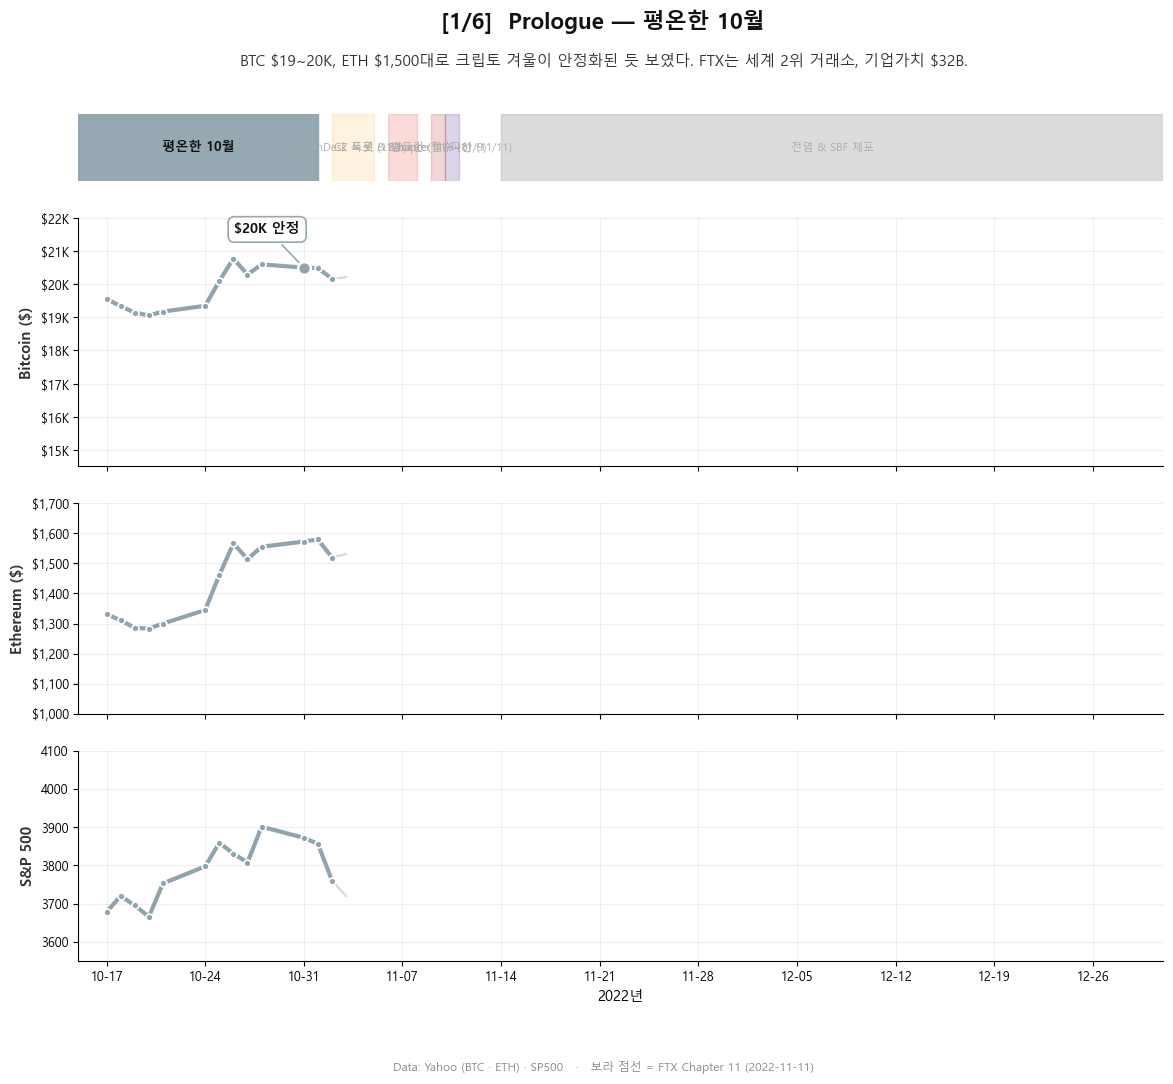

C:\Users\kimch\AppData\Local\Temp\ipykernel_39532\3204474125.py:96: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
c:\Users\kimch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


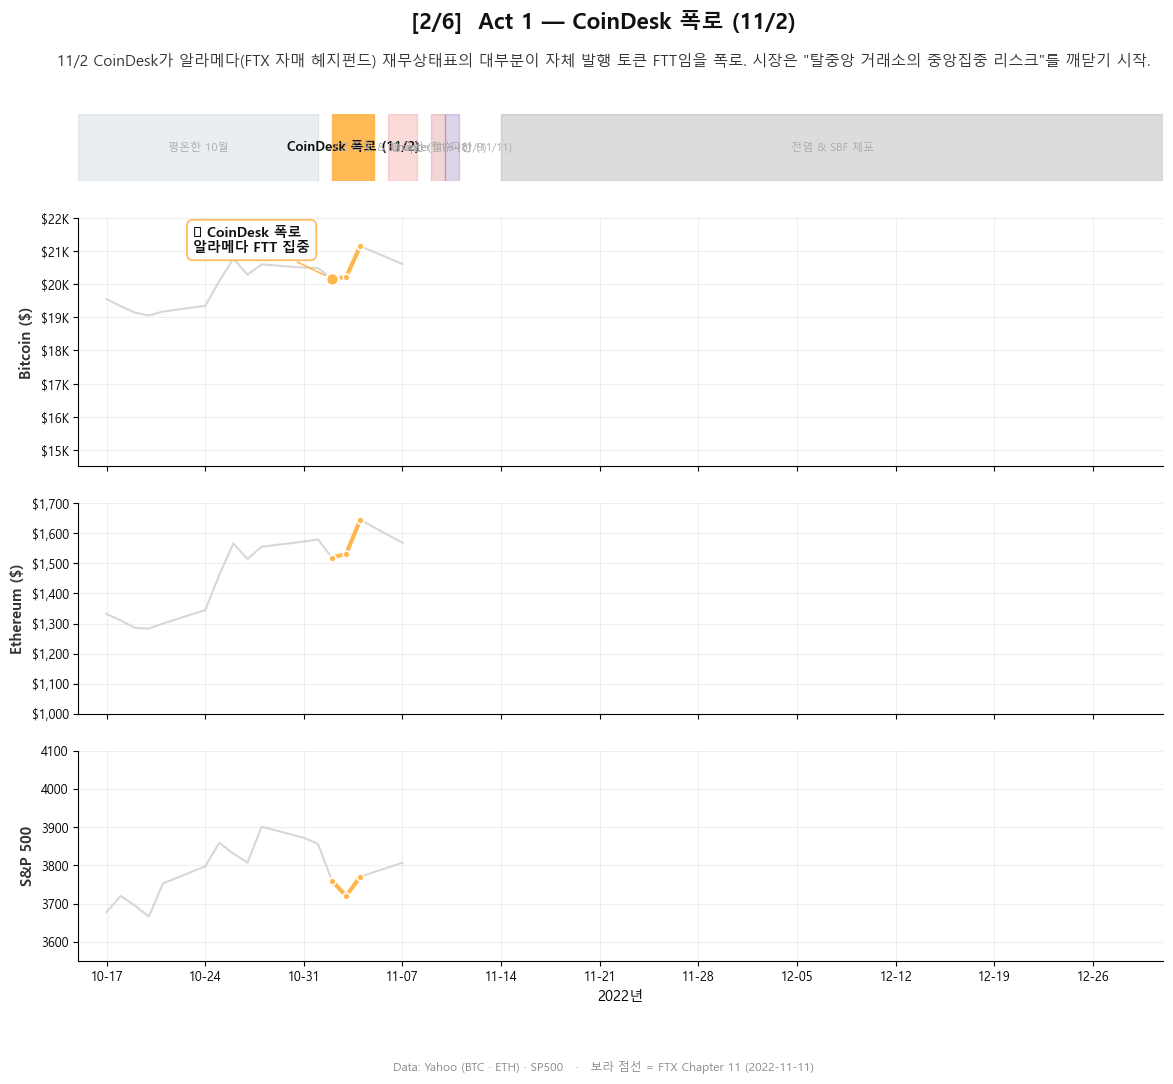

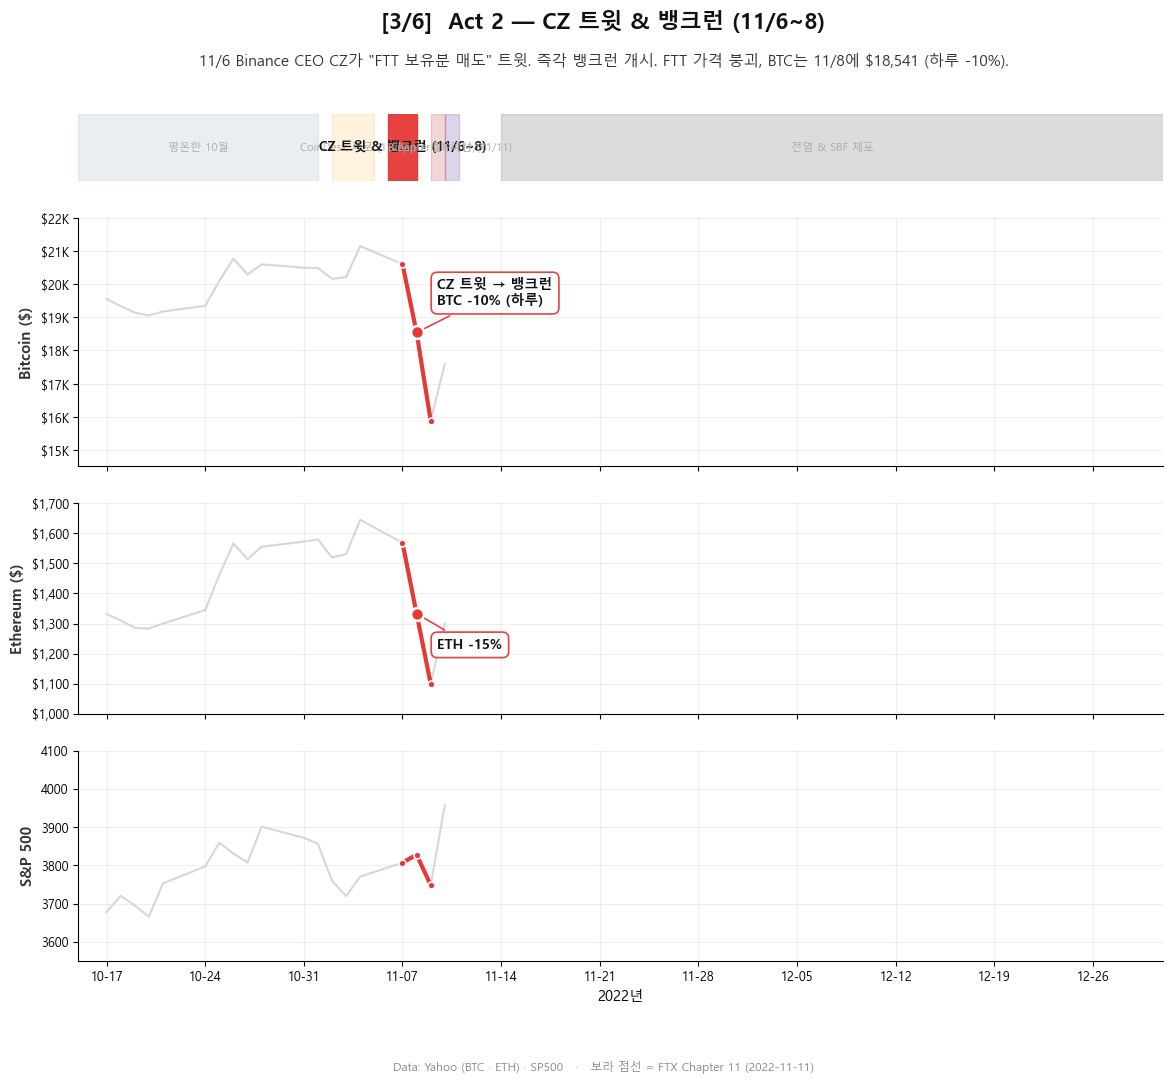

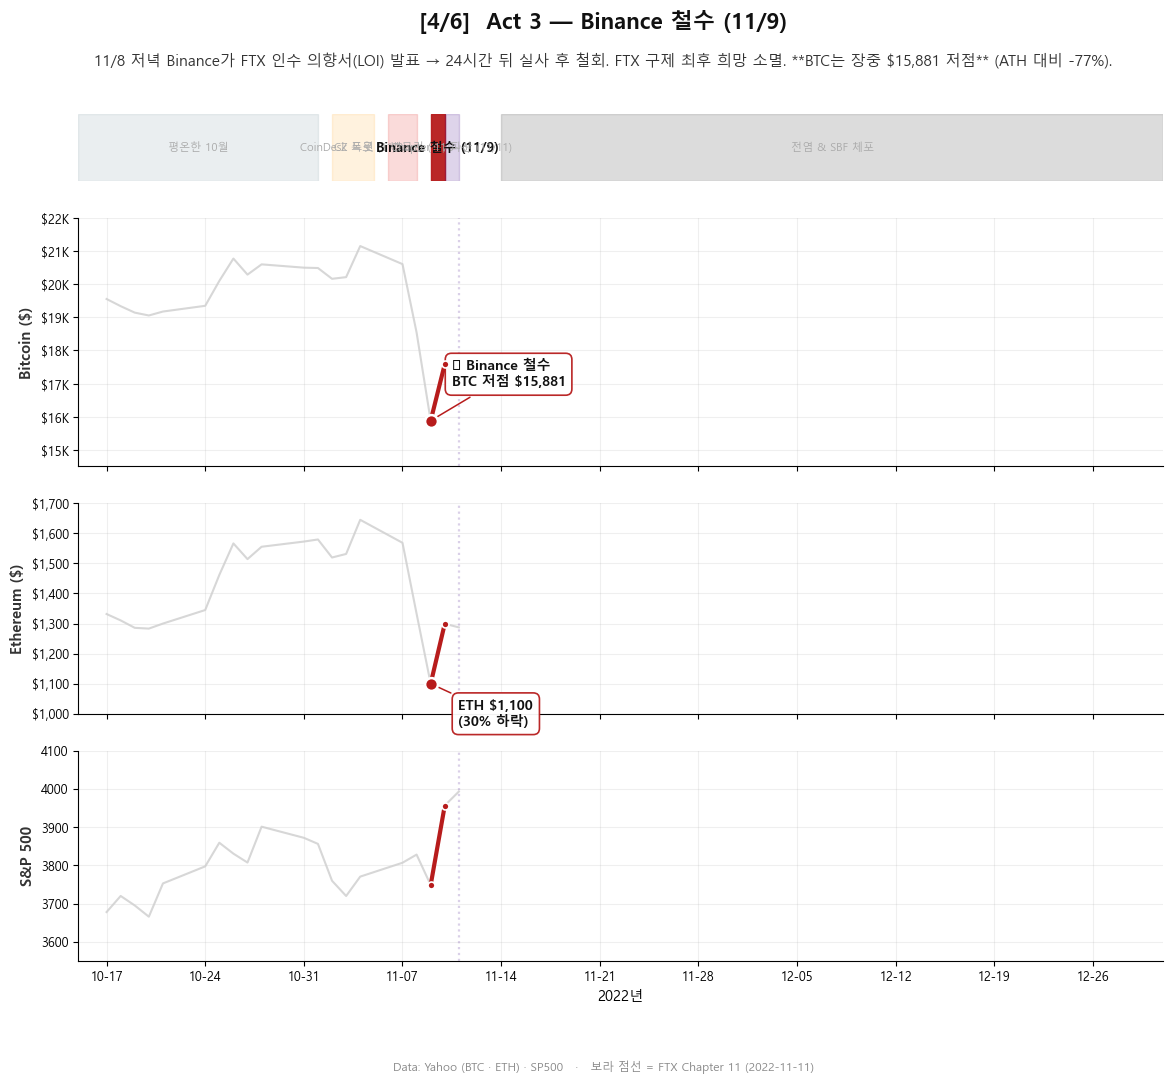

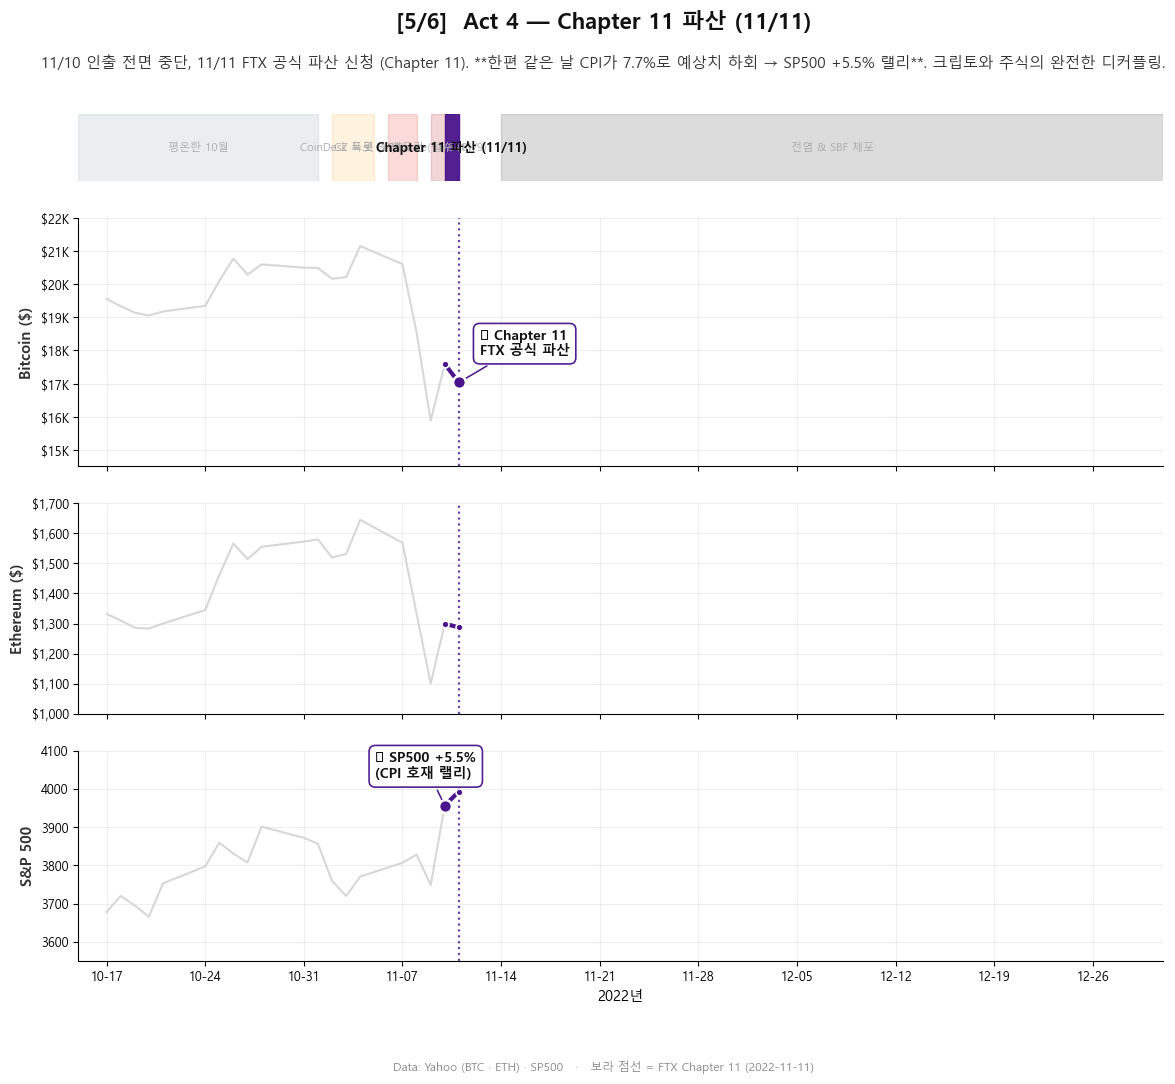

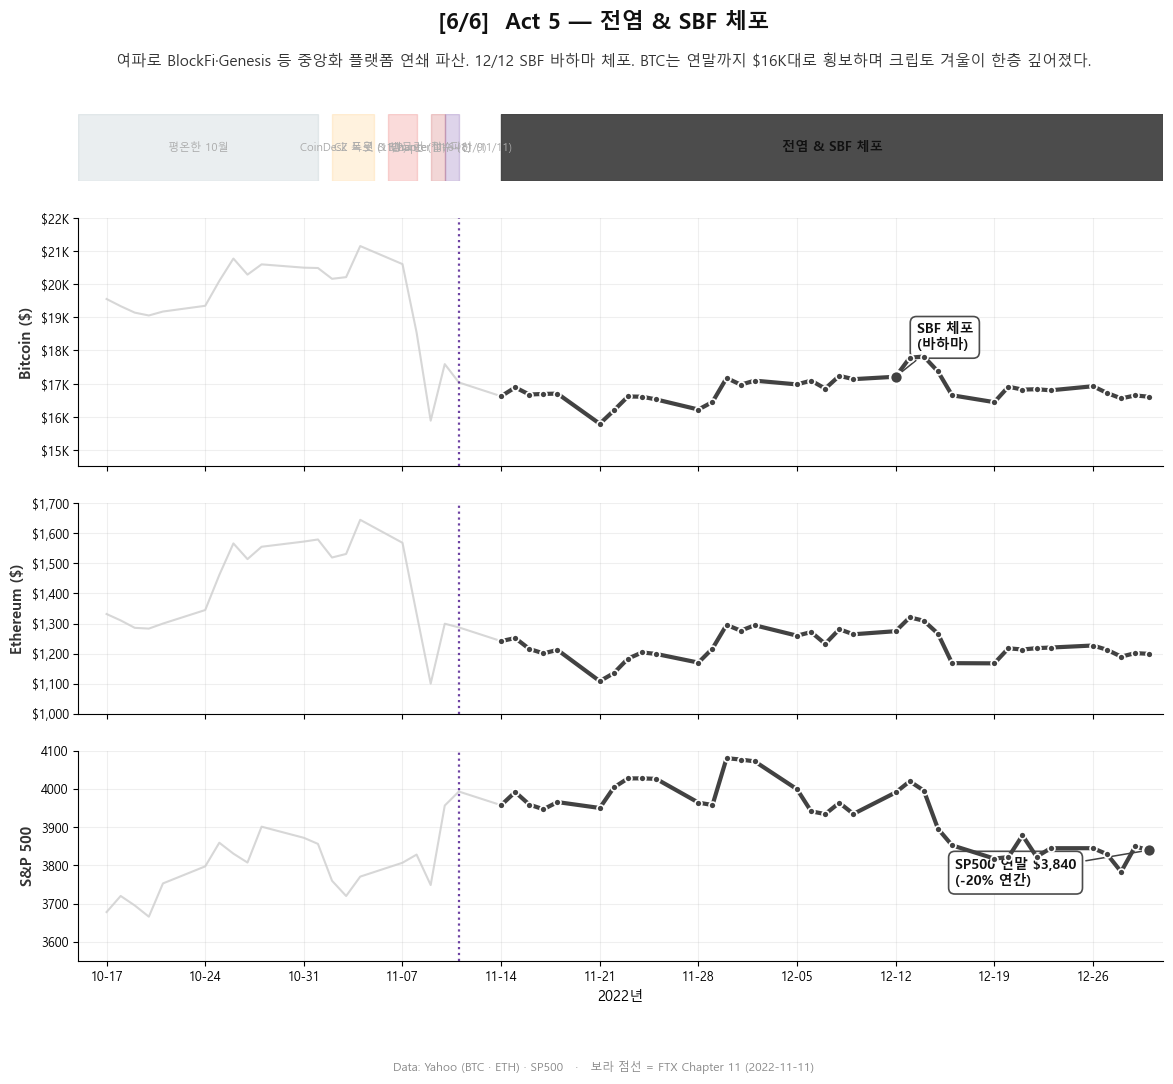

  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e07_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e07_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e07_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e07_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e07_story\04_act4.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e07_story\05_act5.png


In [4]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()
for p in saved:
    print(f'  - {p}')

## 5. 종합 프레임

C:\Users\kimch\AppData\Local\Temp\ipykernel_39532\3669271087.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])
C:\Users\kimch\AppData\Local\Temp\ipykernel_39532\3669271087.py:70: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')


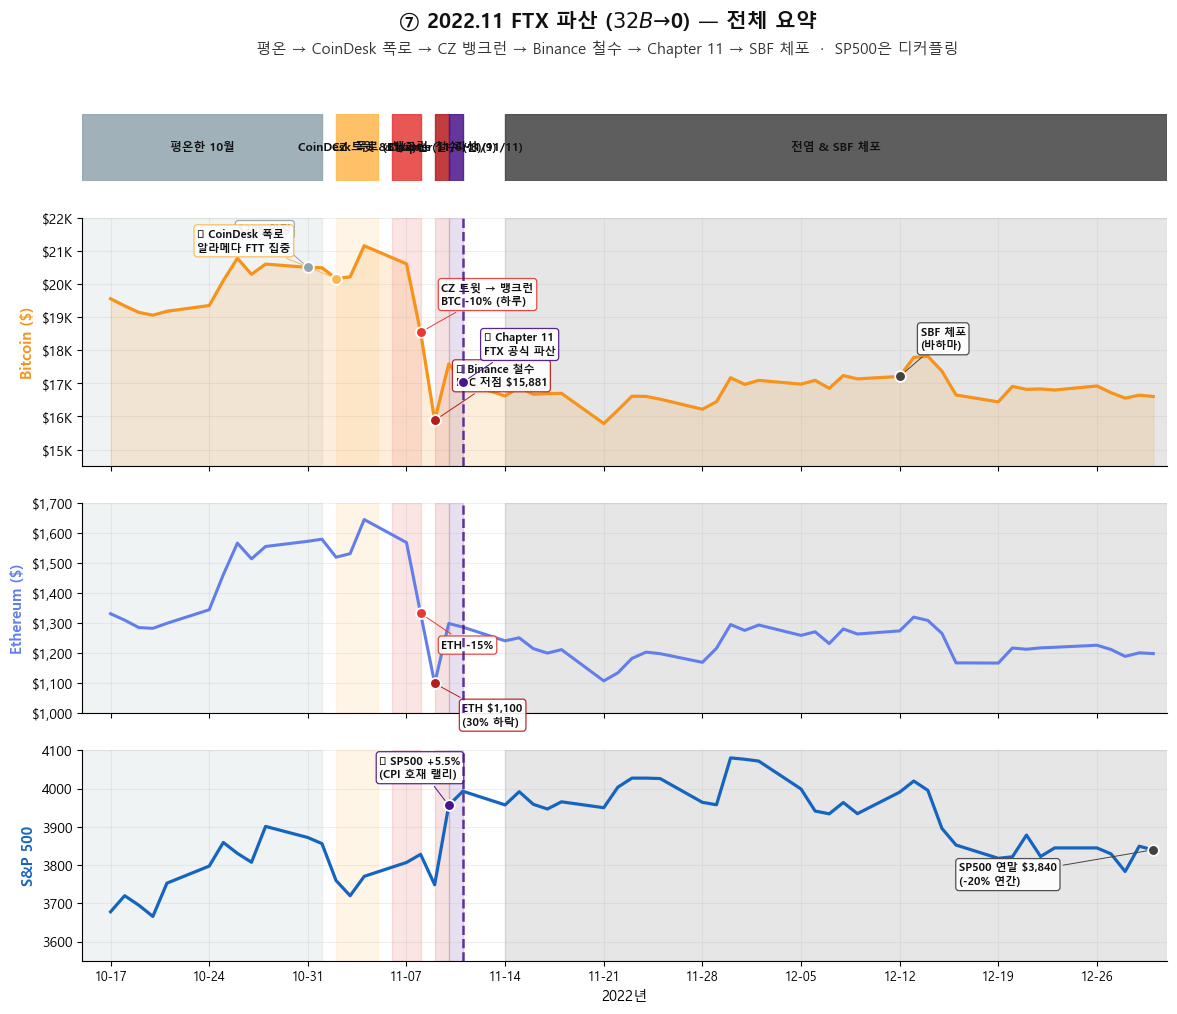


[OK] c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e07_story\99_summary.png


In [5]:
def draw_summary():
    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.35, 1.3, 1.1, 1.1], hspace=0.2)
    ax_rib = fig.add_subplot(gs[0])
    ax_btc = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_eth = fig.add_subplot(gs[2], sharex=ax_rib)
    ax_sp  = fig.add_subplot(gs[3], sharex=ax_rib)

    for pp in phases:
        s = pd.Timestamp(pp['start']); e = pd.Timestamp(pp['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=pp['color'], alpha=0.85)
        short = pp['name'].split('—')[1].strip() if '—' in pp['name'] else pp['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short, ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color='#111')
        for ax in (ax_btc, ax_eth, ax_sp):
            ax.axvspan(s, e, color=pp['color'], alpha=0.13, zorder=0)
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top','right','bottom','left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle('\u2466 2022.11 FTX 파산 ($32B → $0) — 전체 요약',
                 fontsize=15, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935,
             '평온 → CoinDesk 폭로 → CZ 뱅크런 → Binance 철수 → Chapter 11 → SBF 체포  ·  SP500은 디커플링',
             ha='center', fontsize=11, color='#333', style='italic')

    ax_btc.plot(df.index, df['BTC'], color='#F7931A', lw=2.3, zorder=3)
    ax_btc.fill_between(df.index, df['BTC'], YLIM_BTC[0], color='#F7931A', alpha=0.15, zorder=2)
    ax_btc.set_ylabel('Bitcoin ($)', fontsize=10.5, fontweight='bold', color='#F7931A')
    ax_btc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

    ax_eth.plot(df.index, df['ETH'], color='#627EEA', lw=2.2, zorder=3)
    ax_eth.set_ylabel('Ethereum ($)', fontsize=10.5, fontweight='bold', color='#627EEA')
    ax_eth.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    ax_sp.plot(df.index, df['SP500'], color='#1565C0', lw=2.3, zorder=3)
    ax_sp.set_ylabel('S&P 500', fontsize=10.5, fontweight='bold', color='#1565C0')

    ax_btc.set_ylim(YLIM_BTC); ax_eth.set_ylim(YLIM_ETH); ax_sp.set_ylim(YLIM_SP)
    for ax in (ax_btc, ax_eth, ax_sp):
        ax.axvline(BANKRUPTCY, color='#4A148C', linestyle='--', lw=1.8, alpha=0.85, zorder=4)
        ax.grid(alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axmap = {'BTC': ax_btc, 'ETH': ax_eth, 'SP500': ax_sp}
    for phase in phases:
        for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
            ax = axmap[target]
            d = pd.Timestamp(date); c = phase['color']
            ax.scatter([d], [y], s=60, color=c, zorder=6, edgecolors='white', lw=1.3)
            ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=8,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.28', fc='white', ec=c, alpha=0.92, lw=0.9),
                        arrowprops=dict(arrowstyle='-', color=c, lw=0.7))

    ax_sp.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_sp.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_sp.tick_params(axis='x', labelsize=9)
    ax_sp.set_xlabel('2022년', fontsize=10.5)
    for ax in (ax_rib, ax_btc, ax_eth):
        plt.setp(ax.get_xticklabels(), visible=False)

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])
    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

fig, path = draw_summary()
plt.show()
print(f'\n[OK] {path}')